In [50]:
import torch
from yolov5.models.yolo import Model
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

In [148]:
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
model_path = os.path.join(ROOT_DIR, 'models', 'plate_detector.pt')
in_path = os.path.join(ROOT_DIR, 'data', 'all', 'experiment2', 'raw2')
out_path = os.path.join(ROOT_DIR, 'data', 'all', 'experiment2', 'normal')

In [94]:
device = torch.device('cuda')
model = torch.hub.load('ultralytics/yolov5', 'custom', path=model_path, force_reload=True)
model = model.to(device)

Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to C:\Users\ADMIN/.cache\torch\hub\master.zip
YOLOv5  v7.0-416-gfe1d4d99 Python-3.12.7 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)

Fusing layers... 
Model summary: 213 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


In [110]:
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import re

In [140]:
model.conf = 0.50
padding = 30
min_px = 88
idx

1

In [146]:
files = os.listdir(in_path)
existing_files = [file for file in os.listdir(out_path) if file.endswith(('.png', '.jpg'))]
indices = []

for file in existing_files:
    match = re.match(r"(\d+)\.jpg", file)
    if match:
        indices.append(int(match.group(1)))

idx = max(indices) + 1 if indices else 1
idx

11478

In [150]:
"""
    Get the bounding box of the license plate from the image.
    Crop the license plate and save in 'normal' folder
"""

for image_file in files:
    img_path = os.path.join(in_path, image_file)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    result = model(img_rgb)

    boxes = result.xyxy[0]

    for box in boxes:
        x1, y1, x2, y2 = box[:4].cpu().numpy()
        x1 = max(0, int(x1) - padding)
        y1 = max(0, int(y1) - padding)
        x2 = min(img.shape[1], int(x2) + padding)
        y2 = min(img.shape[0], int(y2) + padding)

        # Make width and height divisible by 4
        width = (x2 - x1) - ((x2 - x1) % 4)
        height = (y2 - y1) - ((y2 - y1) % 4)
        x2 = x1 + width
        y2 = y1 + height

        # Ensure we don’t exceed image bounds
        x2 = min(x2, img.shape[1])
        y2 = min(y2, img.shape[0])

        # Draw padded bounding box
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 10)
        cropped_img = img[y1:y2, x1:x2]

        # Save cropped image if above 120 px
        if cropped_img.shape[0] > min_px and cropped_img.shape[1] > min_px:
            crop_filename = f'{out_path}/{idx}.jpg'
            cv2.imwrite(crop_filename, cropped_img)
            print(f'Saved cropped plate: {crop_filename} {image_file}')
            idx += 1
        else:
            print('failed', image_file)

        #plt.figure(figsize=(5, 5))
        #plt.imshow(img_rgb)
        #plt.axis('off')
        #plt.show();

Saved cropped plate: C:\Thesis\LiPAD\data\all\experiment2\normal/11478.jpg -100_jpg.rf.027c7cdb4c086b8ebf97b5b46a28a2e7.jpg
Saved cropped plate: C:\Thesis\LiPAD\data\all\experiment2\normal/11479.jpg -100_jpg.rf.62e0ccd09aad8ce5ed51b205ca49f6d1.jpg
Saved cropped plate: C:\Thesis\LiPAD\data\all\experiment2\normal/11480.jpg -101_jpg.rf.46a28f00c034712ff0727b7e2d71987f.jpg
Saved cropped plate: C:\Thesis\LiPAD\data\all\experiment2\normal/11481.jpg -101_jpg.rf.46a28f00c034712ff0727b7e2d71987f.jpg
Saved cropped plate: C:\Thesis\LiPAD\data\all\experiment2\normal/11482.jpg -101_jpg.rf.d1c46e4c07272de0de474436af08ead5.jpg
Saved cropped plate: C:\Thesis\LiPAD\data\all\experiment2\normal/11483.jpg -101_jpg.rf.d1c46e4c07272de0de474436af08ead5.jpg
Saved cropped plate: C:\Thesis\LiPAD\data\all\experiment2\normal/11484.jpg -102_jpg.rf.5054df3b8ed96b38af34a75b45b9177a.jpg
Saved cropped plate: C:\Thesis\LiPAD\data\all\experiment2\normal/11485.jpg -102_jpg.rf.f15f2b2a0e303dbe36ec00a9c3d49278.jpg
Saved cr

Video resolution: 3840 x 2160


C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Plea

Saved cropped plate: C:\Thesis\LiPAD\data\all\experiment2\normal2\0.jpg (frame 67)


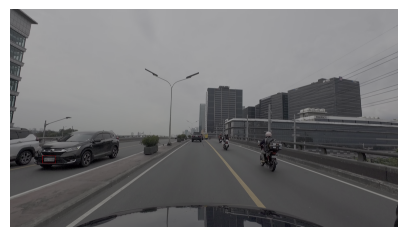

Failed to crop: frame 68


C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


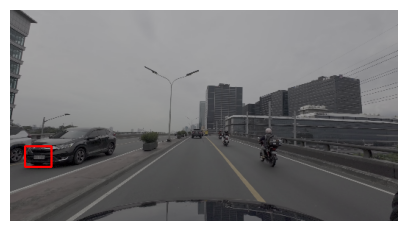

C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Plea

Failed to crop: frame 280


C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


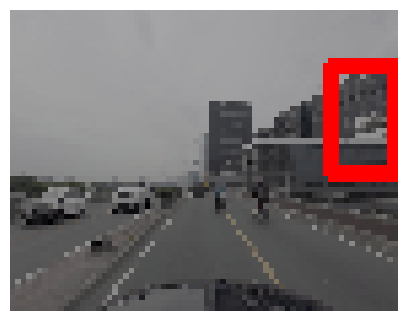

C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Plea

Failed to crop: frame 1241


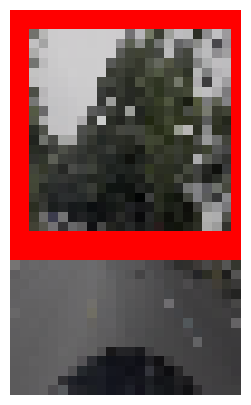

C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Plea

Failed to crop: frame 1254


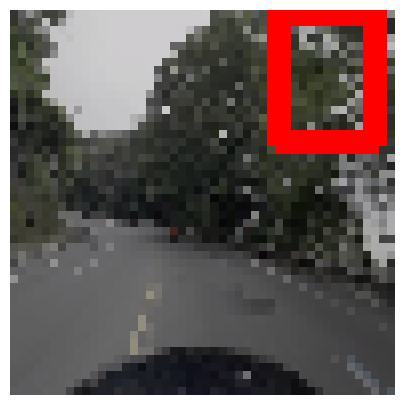

C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Thesis\LiPAD\src\preprocessing\yolov5\models\common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Plea

KeyboardInterrupt: 

In [56]:
import cv2
import os

video_path = os.path.join(ROOT_DIR, 'data', 'all', 'experiment2', '1.webm')
out_path = os.path.join(ROOT_DIR, 'data', 'all', 'experiment2', 'normal2')
os.makedirs(out_path, exist_ok=True)

cap = cv2.VideoCapture(video_path)
width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
print(f"Video resolution: {int(width)} x {int(height)}")
frame_idx = 0
idx = 0
padding = 10
min_px = 96

while cap.isOpened():
    ret, frame = cap.read()
    frame = cv2.resize(frame, (int(width * 2), int(height * 2)))
    if not ret:
        break

    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = model(img_rgb)

    boxes = result.xyxy[0]

    for box in boxes:
        x1, y1, x2, y2 = box[:4].cpu().numpy()
        x1 = max(0, int(x1) - padding)
        y1 = max(0, int(y1) - padding)
        x2 = min(frame.shape[1], int(x2) + padding)
        y2 = min(frame.shape[0], int(y2) + padding)

        # Make width and height divisible by 4
        width = (x2 - x1) - ((x2 - x1) % 4)
        height = (y2 - y1) - ((y2 - y1) % 4)
        x2 = x1 + width
        y2 = y1 + height

        # Ensure we don’t exceed image bounds
        x2 = min(x2, frame.shape[1])
        y2 = min(y2, frame.shape[0])

        # Draw bounding box
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cropped_img = frame[y1:y2, x1:x2]

        if cropped_img.shape[0] > min_px and cropped_img.shape[1] > min_px:
            crop_filename = os.path.join(out_path, f'{idx}.jpg')
            cv2.imwrite(crop_filename, cropped_img)
            print(f'Saved cropped plate: {crop_filename} (frame {frame_idx})')
            idx += 1
        else:
            print(f'Failed to crop: frame {frame_idx}')

        plt.figure(figsize=(5, 5))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show();

    frame_idx += 1

cap.release()
cv2.destroyAllWindows()